# UdaciMed | Notebook 1: Baseline Analysis

Welcome to UdaciMed! You are a Machine Learning Engineer tasked with optimizing our chest X-ray pneumonia detection model for production deployment.

- **The challenge**: Before our new model can be approved for production, we must verify that it meets our strict performance SLAs. Deploying an unoptimized model could lead to high operational costs and poor performance across our diverse hardware fleet—from shared T4 GPU cloud instances to portable clinic devices.

- **Your mission**: Optimize the model to pass _UdaciMed's Universal Performance Standard_, a strict production service level agreement (SLA) that must be met using the universally compatible ONNX format on our standardized target device.

### **Optimization goals**

Your goal is to ensure the production model meets these production targets on our standardized development machine:

- **< 0.4 GFLOPs per sample**: Floating Point Operations determine computational cost - reducing FLOPs is the most critical step toward broad-platform efficiency.
- **< 100MB peak memory footprint**: Total memory consumption (parameters + activations + workspace) during inference - essential for running the model on memory-constrained edge devices and for enabling cost-effective multi-model environments in the cloud.
- **< 3ms latency**: This ensures a real-time user experience. We will measure both *amortized latency* (average time per sample in a large batch) and *true latency* (time for a single-image inference), as both are important for different use cases.
- **> 2000 samples/second throughput**: This specific target is for our high-performance hardware, like the reference T4 GPU. Meeting this goal proves the model is cost-effective and scalable for high-volume, server-side screening workflows.
- **> 98% sensitivity***: This is a non-negotiable clinical safety requirement. We must ensure that a threshold percentage of all true pneumonia cases are correctly identified. All optimizations must be validated against this metric.

#### **A note on our standardized target device**

All performance targets in this project must be met on our official _"standardized target device."_ This is an NVIDIA T4 GPU, a common and versatile datacenter GPU that represents a typical cloud deployment environment.

By using a single, consistent hardware profile (NVIDIA T4 with 16GB VRAM, CUDA 12.4) for all our performance SLAs, we can:

- *Ensure Reproducible Results*: Anyone on the team can validate performance and get consistent measurements.

- *Create a Reliable Benchmark*: It provides a stable baseline to measure the impact of every optimization we make.

If a model can meet our strict, universal performance standards on this reference hardware, we are confident it will perform well across our entire fleet of production devices.

---

Through this notebook, you will build the foundation for our optimization strategy by:

1.  **Establishing baseline performance** with comprehensive profiling.
2.  **Analyzing the primary bottlenecks**, distinguishing between compute, parameter memory, and activation memory.
3.  **Identifying optimization opportunities** in both the model architecture and the deployment configuration.

**Let's set up an optimization vision for UdaciMed's next-generation diagnostic platform!**


> **_\*Understanding medical AI requirements_**:
> 
> In medical AI, sensitivity (recall) is often more critical than overall accuracy. Missing a pneumonia case (false negative) can be life-threatening, while a false positive "only" leads to additional human review. This is why we prioritize sensitivity as our safety constraint.

## Step 1: Set up the environment
The first step is to import all libraries and internal functionalities (from `utils`). 

Additionally, we set `pytorch` to use CUDA GPU if available (not only for faster execution, but also for benchmarking, as this will be our final deployment target!) and we include deterministic mode for reproducible benchmarking.

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

# Build an absolute path from this notebook's parent directory
module_path = os.path.abspath(os.path.join('..', 'utils'))

# Add to sys.path if not already present
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
# Import core libraries
import torch
import torch.nn as nn
import inspect
import numpy as np
import os
import pickle
from pprint import pprint
import random
from torchsummary import summary
import tqdm
import warnings
warnings.filterwarnings('ignore')

# Import project utilities
from data_loader import (
    load_pneumoniamnist, 
    get_dataset_info, 
    explore_dataset_splits,
    visualize_sample_images,
    get_sample_batch
)
from model import (
    create_baseline_model,
    get_model_info,
    count_parameters_by_type,
    train_baseline_model,
    plot_training_history
)
from evaluation import (
    evaluate_with_multiple_thresholds
)
from profiling import (
    PerformanceProfiler,
    get_gpu_info,
    check_environment,
    measure_time
)
from visualization import (
    plot_dataset_distribution,
    plot_performance_profile,
    plot_operation_breakdown,
    plot_batch_size_comparison,
)

# Check environment and GPU capabilities
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    gpu_info = get_gpu_info()
    print(f"GPU: {gpu_info.get('name', 'Unknown')}")
    print(f"GPU Memory: {gpu_info.get('memory_total_gb', 0):.1f} GB")
    print(f"Tensor Core Support: {gpu_info.get('tensor_core_support', False)}")
else:
    print("WARNING: CUDA not available - profiling will be limited")

Using device: cuda
GPU: Tesla T4
GPU Memory: 14.6 GB
Tensor Core Support: True


In [4]:
# Set random seed for reproducibility across optimization experiments
def set_deterministic_mode(seed=42):
    """
    Enable deterministic mode for consistent benchmarking.
    Critical for fair comparison between different techniques.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Disable for consistent timing
    os.environ["PYTHONHASHSEED"] = str(seed)

set_deterministic_mode(42)
print("Deterministic mode enabled for reproducible benchmarking")

Deterministic mode enabled for reproducible benchmarking


In [5]:
# https://github.com/Surveshchauhan/UdaciMed-Efficient-Medical-Diagnostics-with-Hardware-Aware-AI.git

## Step 2: Load and analyze the dataset
Now, we can get started with our baseline model set-up by loading the data and understanding its characteristics. 

For this project, we use the PneumoniaMNIST dataset from [MedMNIST](https://medmnist.com/). PneumoniaMNIST provides a standardized, validated dataset for pneumonia detection research. Its 64x64 resolution balances clinical detail with computational efficiency, making it ideal for optimization studies while maintaining diagnostic relevance.

In [6]:
# Get dataset information
dataset_info = get_dataset_info(use_binary=True)
print("PneumoniaMNIST Dataset Information:")
for key, value in dataset_info.items():
    print(f"   {key.replace('_', ' ').title()}: {value}")

PneumoniaMNIST Dataset Information:
   Name: PneumoniaMNIST
   Task: Binary classification (Normal vs Pneumonia)
   Classes: ['Normal', 'Pneumonia']
   Num Classes: 2
   Source: Chest X-ray Images (Pneumonia) from Kaggle
   Original Size: Various sizes (medical imaging protocols vary)
   Processed Sizes: [28, 64, 128, 224]
   Medical Context: Pneumonia detection in chest X-rays for clinical decision support
   Samples: {'train': 4708, 'val': 524, 'test': 624}
   Total Samples: 5856
   Clinical Significance: Early pneumonia detection critical for patient outcomes
   Preprocessing Note: ImageNet normalization applied for transfer learning optimization


In [7]:
# Define configuration for baseline analysis
CONFIG = {
    'image_size': 64,  # Balanced for for memory usage and model accuracy
    'num_classes': 2,  # Binary classification: normal vs pneumonia
    'batch_size': 32,  # Balanced for memory usage and training stability
    'subset_size': None,  # Use full dataset for production-representative results
}

# Load the dataset with optimized settings
print("Loading PneumoniaMNIST dataset...")

with measure_time("Dataset loading"):
    train_loader = load_pneumoniamnist(
        split="train", download=True, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.7 if CONFIG['subset_size'] is not None else None
    )
    
    val_loader = load_pneumoniamnist(
        split="val", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None
    )
    
    test_loader = load_pneumoniamnist(
        split="test", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None
    )

print(f"Dataset loaded: {CONFIG['image_size']}x{CONFIG['image_size']} images, batch_size={CONFIG['batch_size']}")

Loading PneumoniaMNIST dataset...
Using downloaded and verified file: /voc/work/.medmnist/pneumoniamnist_64.npz
⏱️ Dataset loading took 230.79 ms
Dataset loaded: 64x64 images, batch_size=32


Analyzing dataset distribution...



Dataset Summary: {'train': {'total': 4708, 'class_stats': {'normal': 1214, 'pneumonia': 3494, 'type': 'binary'}, 'normal': 1214, 'pneumonia': 3494, 'pneumonia_ratio': 0.7421410365335599}, 'val': {'total': 524, 'class_stats': {'normal': 135, 'pneumonia': 389, 'type': 'binary'}, 'normal': 135, 'pneumonia': 389, 'pneumonia_ratio': 0.7423664122137404}, 'test': {'total': 624, 'class_stats': {'normal': 234, 'pneumonia': 390, 'type': 'binary'}, 'normal': 234, 'pneumonia': 390, 'pneumonia_ratio': 0.625}}


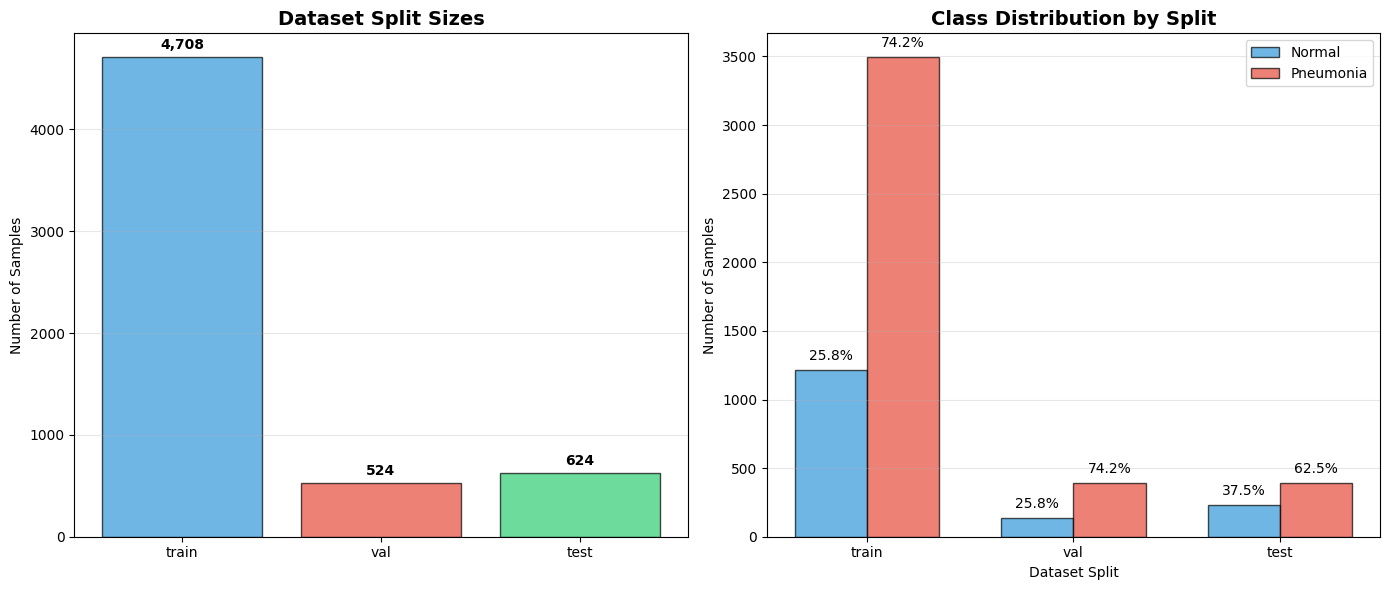

In [8]:
# Analyze dataset distribution for class imbalance considerations
print("Analyzing dataset distribution...")
dataset_splits = explore_dataset_splits(train_loader, val_loader, test_loader)
print(f"\nDataset Summary: {dataset_splits}")

# Visualize dataset distribution
plot_dataset_distribution(dataset_splits)

> **_The impact of class imbalance_**
> 
> Medical datasets often have class imbalance. This affects optimization because:
> 
> - Models may focus compute on majority class features
> - Batch composition affects memory usage patterns
> - Some optimization techniques (like pruning) may disproportionately affect minority class performance

Sample chest X-ray images:


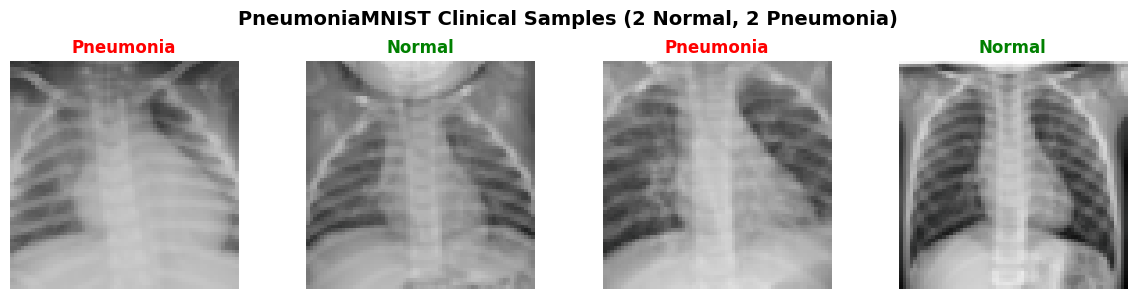

Displayed 4 images: 2 normal, 2 pneumonia


In [9]:
# Visualize sample images to understand data characteristics
print("Sample chest X-ray images:")
visualize_sample_images(train_loader, num_samples=4)

## Step 3: Create and analyze the baseline model
We will use [ResNet-18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) as our baseline - a popular choice for medical imaging that balances accuracy and efficiency.

The original model structure is architected for ImageNet (1000 classes), so we modify the model with a custom head to support our new classification task.

In [10]:
# Create the baseline ResNet-18 model
print("Creating ResNet-18 baseline model...")

baseline_model = create_baseline_model(
    num_classes=CONFIG['num_classes'], 
    input_size=CONFIG['image_size'], 
    pretrained=False  # Training from scratch for fair optimization comparison
)
baseline_model = baseline_model.to(device)

print(f"Baseline model created and deployed to {device}")
print(f"   Architecture: {baseline_model.architecture_name}")

Creating ResNet-18 baseline model...
Baseline model created and deployed to cuda
   Architecture: ResNet-18-Adaptive


In [11]:
# Get model information
model_info = get_model_info(baseline_model)

print(f"\nModel Information:")
print(f"   Architecture: {model_info['architecture']}")
print(f"   Total Parameters: {model_info['total_parameters']:,}")
print(f"   Model Size: {model_info['model_size_mb']:.1f} MB")
print(f"   Input Size: {model_info['input_size']}x{model_info['input_size']}")

# Analyze layer composition 
layer_breakdown = model_info['layer_breakdown']
print(f"\nLayer Composition:")
print(f"   Convolution Layers: {layer_breakdown['conv_layers']['count']} ({layer_breakdown['conv_layers']['total_params']:,} params)")
print(f"   Linear Layers: {layer_breakdown['linear_layers']['count']} ({layer_breakdown['linear_layers']['total_params']:,} params)")
print(f"   Normalization Layers: {layer_breakdown['norm_layers']['count']}")
print(f"   Activation Types: {', '.join(layer_breakdown['activation_layers']['types'])}")

# Get parameter distribution
if 'parameter_distribution' in layer_breakdown:
    param_dist = layer_breakdown['parameter_distribution']
    print(f"\nParameter Distribution:")
    print(f"   Convolution: {param_dist['conv_percentage']:.2f}%")
    print(f"   Linear: {param_dist['linear_percentage']:.2f}%")


Model Information:
   Architecture: ResNet-18-Adaptive
   Total Parameters: 11,177,538
   Model Size: 42.6 MB
   Input Size: 64x64

Layer Composition:
   Convolution Layers: 20 (11,166,912 params)
   Linear Layers: 1 (1,026 params)
   Normalization Layers: 20
   Activation Types: ReLU

Parameter Distribution:
   Convolution: 99.99%
   Linear: 0.01%


In [12]:
# Display the model architecture
summary(baseline_model, input_size=(3, CONFIG["image_size"], CONFIG["image_size"]))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

> **_Brainstorming time: Optimizations by layer type_**
> 
> Try to remember from the course, which architectural optimizations most benefit each layer type? Looking at the layer composition, our model is convolution-heavy - this is your starting point!

## Step 4: Train and evaluate baseline model
Now, we define the baseline model and evaluate its performance on key accuracy metrics - all future optimizations should maintain a similar clinical performance standard.

Establishing robust baseline metrics is crucial for medical AI. Any optimization must preserve clinical safety while improving computational efficiency.

Starting baseline model training for pneumonia detection...
   Config: 10 epochs, lr=0.0003, wd=0.0001


Epoch 1/10 [Train]:   0%|                                                   | 0/148 [00:00<?, ?it/s]

   Epoch  1: Train Acc  92.4% | Val Acc  29.8% | Train Loss 0.2016 | Val Loss 12.0479 | LR 0.000300
      New best model saved (Val Acc: 29.8%)


   Epoch  2: Train Acc  95.5% | Val Acc  86.6% | Train Loss 0.1251 | Val Loss 0.3416 | LR 0.000300
      New best model saved (Val Acc: 86.6%)


   Epoch  3: Train Acc  96.1% | Val Acc  94.8% | Train Loss 0.1151 | Val Loss 0.1230 | LR 0.000300
      New best model saved (Val Acc: 94.8%)


...

   Epoch  6: Train Acc  98.7% | Val Acc  97.1% | Train Loss 0.0364 | Val Loss 0.0803 | LR 0.000030


   Epoch  7: Train Acc  99.2% | Val Acc  97.7% | Train Loss 0.0291 | Val Loss 0.0720 | LR 0.000003
      New best model saved (Val Acc: 97.7%)


   Epoch  8: Train Acc  99.2% | Val Acc  97.9% | Train Loss 0.0224 | Val Loss 0.0709 | LR 0.000003
      New best model saved (Val Acc: 97.9%)


   Epoch  9: Train Acc  99.2% | Val Acc  97.7% | Train Loss 0.0211 | Val Loss 0.0678 | LR 0.000003


   Epoch 10: Train Acc  99.1% | Val Acc  97.7% | Train Loss 0.0243 | Val Loss 0.0686 | LR 0.000000
Training completed! Best validation accuracy: 97.90%


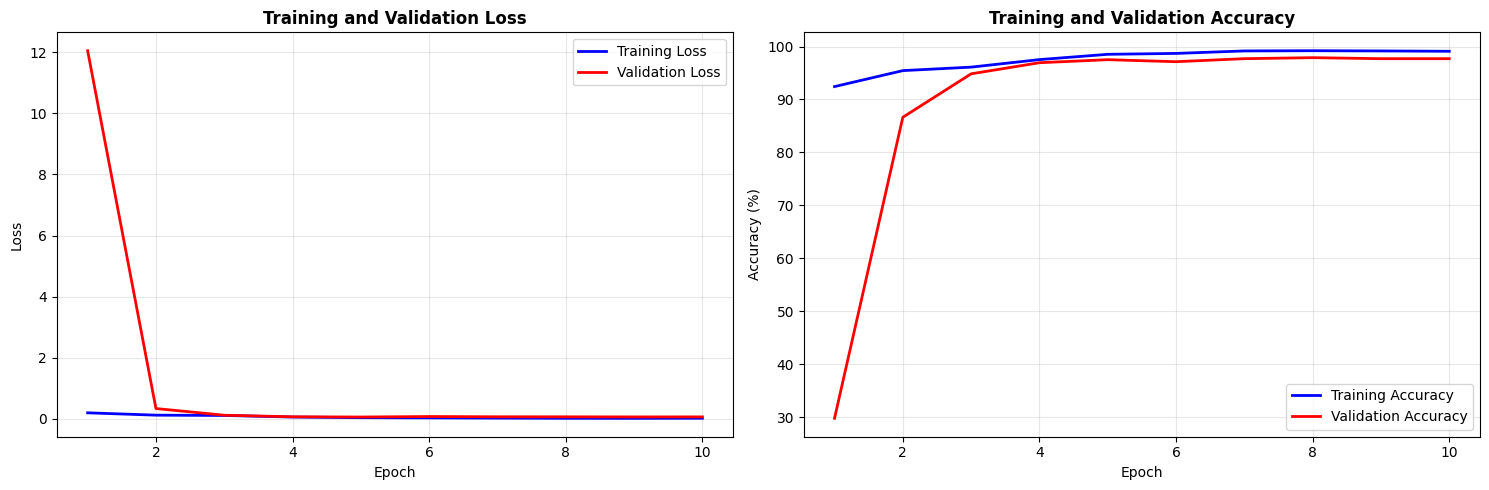


Training Summary:
   Best Validation Accuracy: 97.9%
   Total Epochs: 10
   Final Training Accuracy: 99.1%
   Final Validation Accuracy: 97.7%


In [13]:
# Training configuration
TRAINING_CONFIG = {
    'num_epochs': 10,           # Sufficient for convergence analysis
    'learning_rate': 0.0003,    # Conservative rate for stable training
    'lr_step_size': 3,          # Learning rate decay schedule
    'weight_decay': 1e-4,       # Regularization for generalization
    'patience': 3               # Early stopping for efficiency
}

# Train the model
baseline_model, training_history = train_baseline_model(
    baseline_model, train_loader, val_loader, device, TRAINING_CONFIG
)

# Plot training curves with analysis
plot_training_history(training_history)

> **Training insights: What does the training history tell us?**
> 
> The initial low validation accuracy is due to extreme overfitting due to the small dataset size in comparison to the model's parameter size. The presence of early plateaus and fast convergence also highlight that the architecture has high representational power - we can likely apply aggressive optimization without accuracy degradation.

In [14]:
# Evaluate model performance with multiple thresholds 
print(f"Running eval benchmark on {dataset_splits['test']['total']} test samples ...")
eval_results = evaluate_with_multiple_thresholds(baseline_model, test_loader, device, [0.4, 0.7])

Running eval benchmark on 624 test samples ...

Evaluating with threshold 0.4:


Clinical Evaluation Results (threshold: 0.400):
   Accuracy:  86.5%
   Precision: 82.4% (PPV - Positive Predictive Value)
   Recall:    99.7% (Sensitivity)
   F1 Score:  90.3%
   AUC-ROC:   0.965

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     151
   False Positives (Normal misclassified):            83
   False Negatives (Pneumonia missed):                 1
   True Positives (Pneumonia correctly detected):   389

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     99.7% (detects 99.7% of pneumonia cases)
   Specificity (True Negative Rate):     64.5% (correctly identifies 64.5% of normal cases)
   PPV (Positive Predictive Value):      82.4% (when model predicts pneumonia, it's correct 82.4% of time)
   NPV (Negative Predictive Value):      99.3% (when model predicts normal, it's correct 99.3% of time)

Clinical Significance:
   False Negative Rate: 0.3% (missed pneumonia cases - critical for patient safety)
   False Positive 

> **Clinical threshold selection**
>
> Different thresholds optimize for different clinical scenarios. Lower thresholds (0.4) maximize sensitivity for screening, while higher thresholds (0.7) balance precision and recall for diagnostic confirmation.

## Step 5: Profile baseline model for latency, throughput, and memory usage

Comprehensive performance profiling forms the foundation of our optimization strategy. We will measure all key metrics that impact multi-tenant deployment.

In [15]:
# Initialize performance profiler
profiler = PerformanceProfiler(device=str(device))
print(f"Performance profiler initialized for {device}")

# Get sample batch for profiling
sample_images, sample_labels = get_sample_batch(val_loader)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

print(f"\nSample batch for profiling:")
print(f"   Batch shape: {sample_images.shape}")
print(f"   Memory usage: {sample_images.numel() * sample_images.element_size() / 1024**2:.1f} MB")

Performance profiler initialized for cuda

Sample batch for profiling:
   Batch shape: torch.Size([32, 3, 64, 64])
   Memory usage: 1.5 MB


In [16]:
# Profile inference timing
print("Profiling inference timing...")

timing_results = profiler.profile_inference_time(
    model=baseline_model,
    input_tensor=sample_images,
    num_runs=100,       # Sufficient for statistical significance
    warmup_runs=10      # GPU warmup for consistent measurements
)

print(f"\nTiming Results:")
print(f"   Single Sample Latency: {timing_results['single_sample_ms']:.2f} ms")
print(f"   (Single) Batch Throughput: {timing_results['throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Batch Latency: {timing_results['batch_total_ms']:.2f} ms")
print(f"   Batch Throughput: {timing_results['batch_throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Mean Inference Time: {timing_results['mean_ms']:.2f} ms")
print(f"   95th Percentile: {timing_results['p95_ms']:.2f} ms")
print(f"   Standard Deviation: {timing_results['std_ms']:.2f} ms")

Profiling inference timing...



Timing Results:
   Single Sample Latency: 2.91 ms
   (Single) Batch Throughput: 343.9 samples/sec
   Batch Latency: 25.69 ms
   Batch Throughput: 1245.5 samples/sec
   Mean Inference Time: 2.91 ms
   95th Percentile: 3.31 ms
   Standard Deviation: 0.21 ms


> **Latency vs throughput trade-offs**
>
> Single sample latency measures real-time diagnostic speed, while batch throughput indicates multi-tenant efficiency. Both metrics are crucial for different deployment scenarios.

In [17]:
# Profile FLOPs for computational efficiency analysis
flops_results = profiler.profile_flops(
    model=baseline_model, 
    input_tensor=sample_images
)

if 'error' in flops_results:
    print(f"FLOPs calculation failed: {flops_results['error']}")
else:
    print(f"\nFLOPs Results:")
    print(f"   Total: {flops_results['total_gflops']:.2f} GFLOPs")
    print(f"   Per Sample: {flops_results['gflops_per_sample']:.2f} GFLOPs")
    if 'module_percentage' in flops_results and flops_results['module_percentage']:
        print(f"\n   Top Operations (by FLOPs):")
        for module, percentage in list(flops_results['module_percentage'].items())[:5]:
            gflops = flops_results['module_breakdown_gflops'][module]
            print(f"     {module}: {percentage:.1f}% ({gflops:.2f} GFLOPs)")

Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)



FLOPs Results:
   Total: 58.21 GFLOPs
   Per Sample: 1.82 GFLOPs

   Top Operations (by FLOPs):
     conv: 99.7% (58.03 GFLOPs)
     batch_norm: 0.3% (0.16 GFLOPs)
     upsample_bilinear2d: 0.0% (0.02 GFLOPs)
     adaptive_avg_pool2d: 0.0% (0.00 GFLOPs)
     linear: 0.0% (0.00 GFLOPs)


In [18]:
# Profile GPU memory usage
print("Profiling GPU memory usage...")

memory_results = profiler.profile_memory_usage(
    model=baseline_model,
    input_tensor=sample_images
)

if 'error' not in memory_results:
    print(f"\nMemory Results:")
    print(f"   Peak GPU Memory: {memory_results['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase: {memory_results['memory_increase_mb']:.1f} MB")
    
    # Component breakdown
    if 'component_breakdown' in memory_results:
        components = memory_results['component_breakdown']
        print(f"\nMemory Component Breakdown:")
        for component, usage in components.items():
            print(f"   {component.replace('_', ' ').title()}: {usage:.1f} MB")
else:
    print(f"WARNING: Memory profiling error: {memory_results['error']}")
    memory_results = {}

Profiling GPU memory usage...

Memory Results:
   Peak GPU Memory: 330.5 MB
   Memory Increase: 227.2 MB

Memory Component Breakdown:
   Model Parameters Mb: 42.6 MB
   Input Tensor Mb: 1.5 MB
   Output Tensor Mb: 0.0 MB
   Activations Mb: 225.7 MB


> **_Did you notice? A major optimization opportunity hiding in plain sight!_**
> 
> Look carefully at the model summary above. Something doesn't add up with our input/output dimensions...
> 
> Compare the input size we are feeding (64x64) with the first convolution layer's output size. The first Conv2d layer shows output `[-1, 64, 112, 112]` but our input is only 64x64. Where are those extra pixels coming from? Complete the TODO below to find out.
> 
> *Optimization opportunity:* This might be your biggest single optimization win, in both speed and memory usage! Keep this insight in mind as you analyze the profiling results below.

In [19]:
# Inspect the baseline model's forward method using `inspect.get_source()`
print("Manually inspect the ResNetBaseline forward method:")
baseline_model_forward = inspect.getsource(type(baseline_model).forward)
print(baseline_model_forward)

print("\nDiscussion questions:")
print("1. What happens when height != self.target_size? What is self.target_size set to?") 
print("2. How much computational and memory overhead does F.interpolate add? (Hint: Compare 64x64 vs 224x224 pixel counts)")
print("3. Is this interpolation necessary for pneumonia detection, or just a legacy from ImageNet pretraining?")

Manually inspect the ResNetBaseline forward method:
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with adaptive input interpolation for variable input sizes.
        
        Automatically handles input size adaptation to leverage ImageNet pretrained
        features optimally. Critical for medical imaging where input sizes may vary
        across different acquisition protocols.
        
        Args:
            x: Input tensor of shape (batch_size, channels, height, width)
            
        Returns:
            Output logits of shape (batch_size, num_classes) for classification
            
        Note:
            Bilinear interpolation maintains spatial relationships in medical images
            while adapting to the expected ImageNet input size for optimal
            pretrained feature utilization.
            
        Example:
            >>> model = ResNetBaseline()
            >>> input_tensor = torch.randn(8, 3, 28, 28)  # Vari

In [20]:
# Detailed PyTorch profiler
print("Running detailed PyTorch profiler...")

detailed_results = profiler.profile_with_pytorch_profiler(
    model=baseline_model,
    input_tensor=sample_images,
    num_steps=10        # Sufficient for operation breakdown analysis
)

if 'error' not in detailed_results:
    print(f"\nOperation Breakdown:")
    op_breakdown = detailed_results['operation_breakdown']
    
    # Show top operations for optimization targeting
    sorted_ops = sorted(op_breakdown.items(), key=lambda x: x[1], reverse=True)
    for op_type, percentage in sorted_ops:
        if percentage > 1:  # Only show operations > 1%
            print(f"   {op_type.replace('_', ' ').title()}: {percentage:.1f}%")
else:
    print(f"WARNING: Detailed profiling error: {detailed_results['error']}")
    detailed_results = {}

Running detailed PyTorch profiler...



Operation Breakdown:
   Convolution Ops: 45.4%
   Normalization Ops: 30.2%
   Other Ops: 15.4%
   Activation Ops: 4.4%
   Matrix Multiply Ops: 3.2%
   Pooling Ops: 1.0%


## Step 6: Visualize and save baseline model's performance

Comprehensive visualization helps understand optimization opportunities and track progress across optimization experiments.

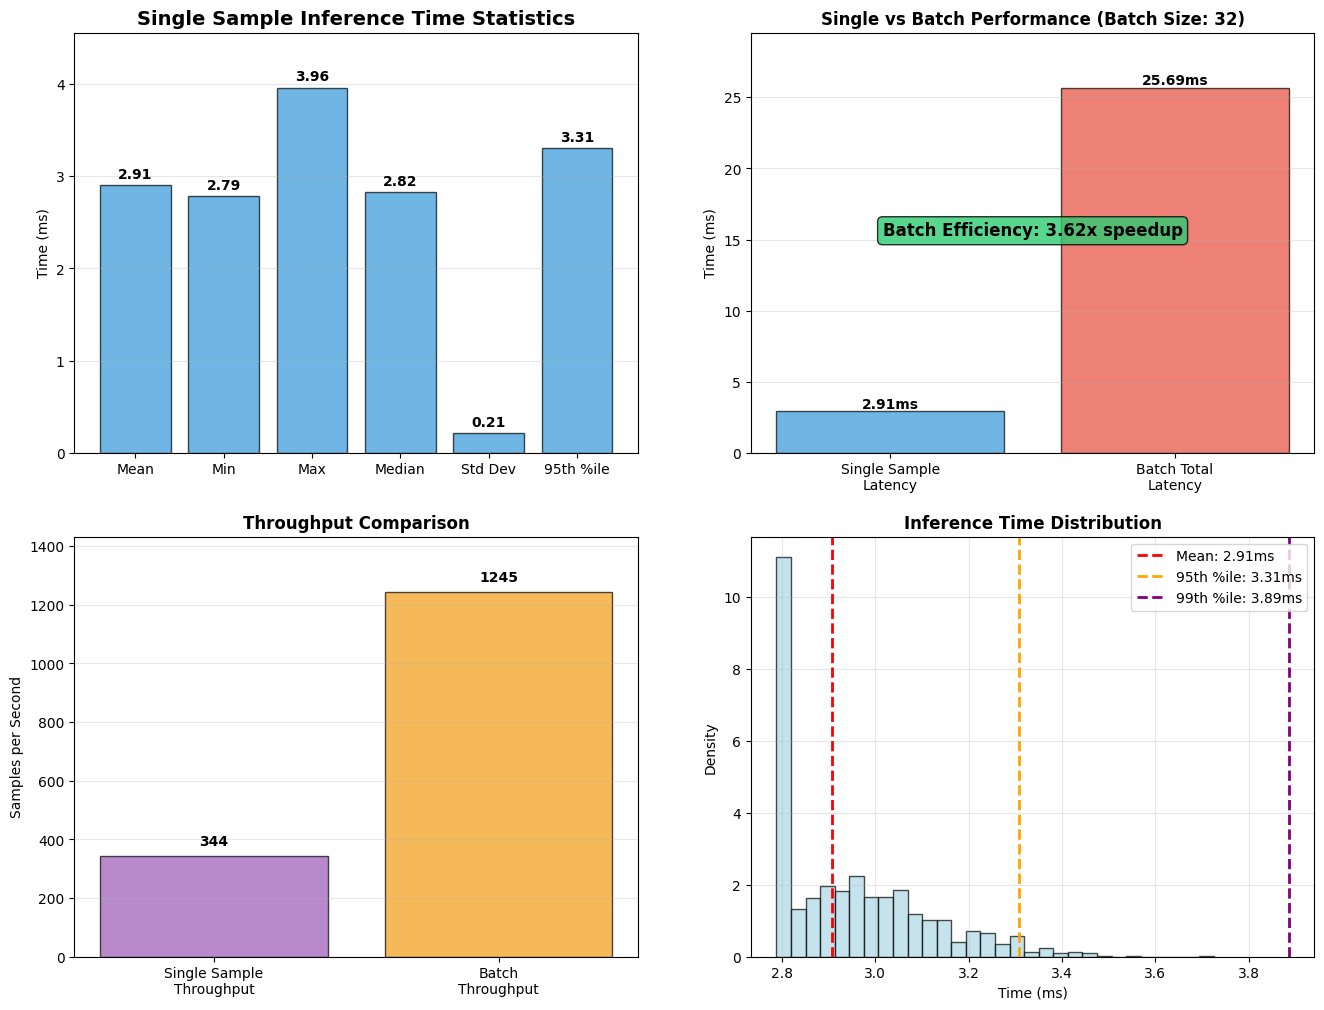

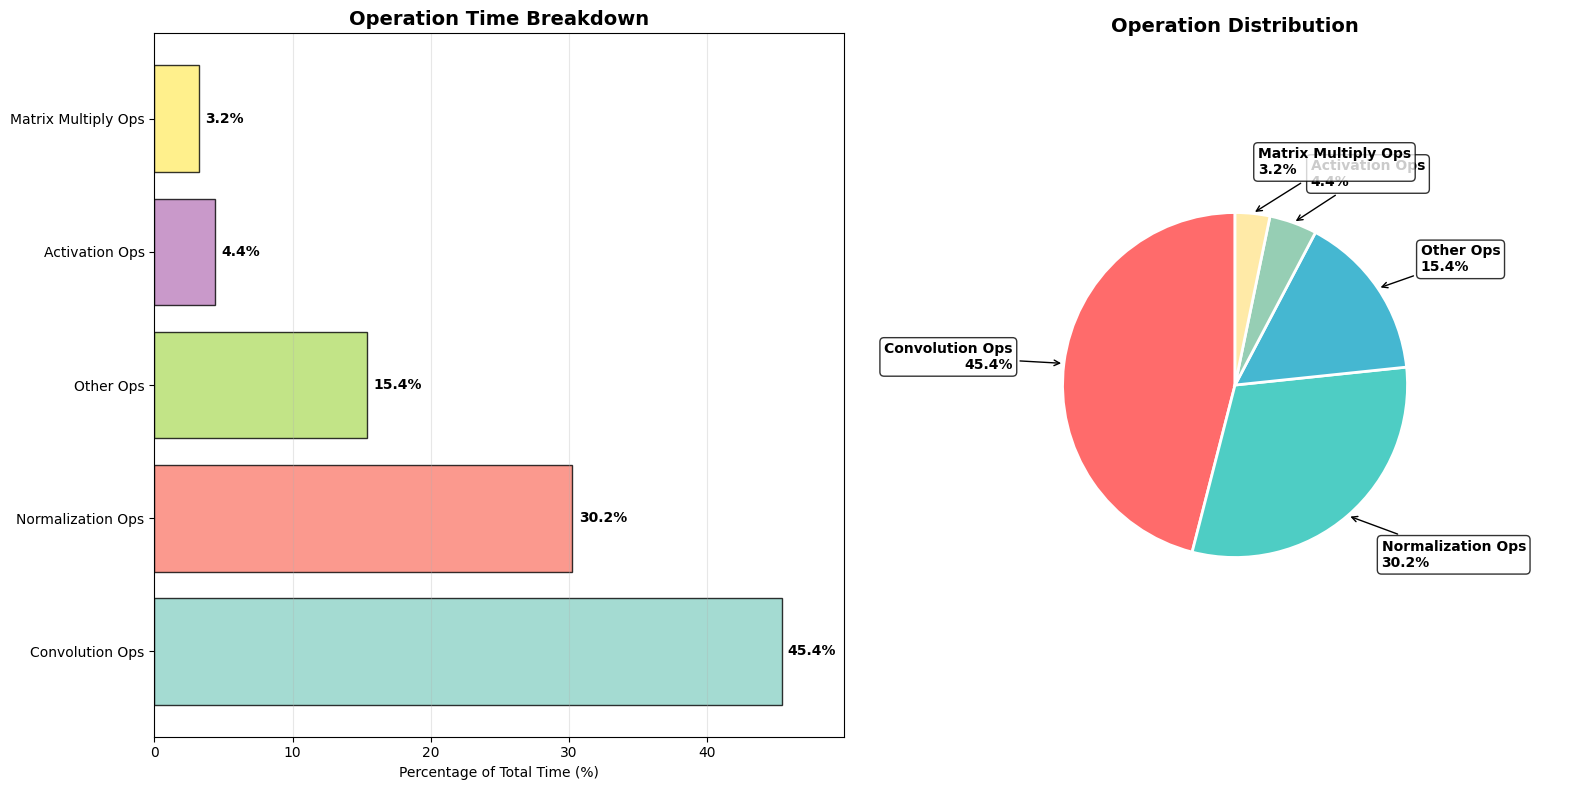

In [21]:
# Visualize performance profile
plot_performance_profile(timing_results)

# Visualize operation breakdown
if detailed_results and 'operation_breakdown' in detailed_results:
    plot_operation_breakdown(detailed_results['operation_breakdown'])
else:
    print("WARNING: Operation breakdown visualization not available")

In [22]:
# Compile baseline results for optimization notebooks
baseline_results = {
    'model_name': 'ResNet-18 Baseline',
    'architecture': model_info['architecture'],
    'total_parameters': model_info['total_parameters'],
    'model_size_mb': model_info['model_size_mb'],
    'config': CONFIG,
    'eval_results': eval_results,
    'timing': timing_results,
    'flops': flops_results,
    'memory': memory_results,
    'operation_breakdown': detailed_results['operation_breakdown'],
    'model_info': model_info,
    'dataset_info': dataset_info,
    'parameter_breakdown': count_parameters_by_type(baseline_model)
}

# Save baseline results
with open('../results/baseline_results.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print("Baseline results saved to 'baseline_results.pkl' in the `results/` folder")
print("   This will be used for comparison in optimization notebooks.")

Baseline results saved to 'baseline_results.pkl' in the `results/` folder
   This will be used for comparison in optimization notebooks.


> **Brainstorming time!**
> 
> Based on your profiling results above, analyze the following:
> 
> 1. **Primary bottleneck**: What is the main performance bottleneck - compute time, memory usage, or data transfer?
> 
> 2. **Operation analysis**: Which types of operations (convolution, linear, activation) consume the most time? What percentage?
> 
> 3. **Memory patterns**: How much memory does the model use during inference? What contributes most to memory usage?
> 
> 4. **Optimization priority**: Based on the profiling data, which optimization techniques would you prioritize:
>    - Architecture modifications (channel reduction, efficient blocks)
>    - Precision optimization (mixed precision, quantization)
>    - Hardware acceleration (TensorRT for GPU, ...)
>   
>    _IMPORTANT:_ Did you discover the major inefficiency we hinted at earlier? How much improvement could removing the 64→224 interpolation provide?

---

## Step 7: Analyze optimization opportunities

Now that we have established the baseline performance, it's time for you to conduct a deeper analysis that will guide the optimization strategy. This section contains **two focused analysis checkpoints**:

1. **Architecture optimization analysis** - Identify specific opportunities in the ResNet-18 architecture
2. **Deployment optimization analysis** - Understand hardware acceleration and deployment strategies

Complete these analysis checkpoints to develop your optimization roadmap!

### Analysis checkpoint 1: Architecture optimization opportunities

**Task:** Analyze the ResNet-18 architecture to identify the **top 2 optimization opportunities** from the techniques covered in the course. Available techniques to consider include:
- Grouped convolutions
- Depth-wise separable convolutions
- Inverted residuals with linear bottlenecks
- Low-rank factorization
- Channel organization strategies _(NOTE: this is a hybrid optimization between architecture and hardware)_
- Parameter sharing / weight tying

Feel free to skip programmatic analysis of techniques which you deem to be non-applicable or less performant, but provide an explanation here or in the notebook's final markdown cell.

**IMPORTANT:** Don't forget to also analyze the potential of interpolation removal from the model's forward method!

#### Recommended strategic analysis approach

Calculate the expected impact of applying each technique on parameter reduction programmatically to simplify follow-up analysis. Consider how parameter reduction / architectural improvements for each technique correlate with memory size (activation vs parameters), FLOPs, latency, throughput, and sensitivity to estimate optimization opportunity. HINTS are in each function's signature.

To populate the analysis dictionary with estimated optimiation opportunity, you can either:
1. Programmatically calculate optimization opportunity from parameter reduction and rule-of-thumb
2. Directly add the expected value in the analysis entries, and add a one-line explanation of the value selected as an in-line comment.

In [30]:
## Implement logic for each single technique analysis

def analyze_grouped_conv_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"]), groups=2):
    """
    TODO: Analyze which convolution layers could benefit from grouped convolutions.

    HINT: Look for standard convolutions with kernel_size > 1 and sufficient channels that are divisible by groups
    
    Memory impact: Note that parameter memory is only ~13% of total memory in ResNet-18
    FLOP improvements: Update the `in_ch × out_ch × kernel²` calculation for standard conv to account for `groups` division
    Speedup: Proportional to FLOP reduction, but may have overhead from grouped operations on **parallel hardware**
    Throughput: Can be limited by memory bandwidth and **hardware utilization** patterns for grouped operations.
    
    Also, note that, some backends (like CUDA/CUDNN) may require specific memory formats (e.g., channels_last) and mixed precision to unlock maximum throughput for grouped convolutions.
    This is a known issue: https://discuss.pytorch.org/t/performing-convolutions-in-groups-but-not-grouped-convolution/59412/27
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Grouped Convolutions',
        'groups': groups,
        'candidate_layers': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'avg_param_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': 'May degrade accuracy if channel grouping disrupts learned spatial correlations or if hardware backend does not efficiently support grouped operations.'

    }

    # TODO: Complete the analysis dictionary with relevant values
    # HINT:
    # 1. Find candidates: for name, module in model.named_modules() if isinstance(module, nn.Conv2d) and module.kernel_size[0] > 1 and module.groups == 1 and module.in_channels % groups == 0
    # 2. Calculate per-layer: grouped_params = standard_params // groups, then param_reduction = (standard_params - grouped_params) / standard_params
    # 3. Aggregate impact: total_flops_saved += per_layer_savings, then realistic_speedup = 1 / (1 - flop_reduction_ratio * conv_coverage * hardware_efficiency_factor)
    total_params_saved = 0
    total_flops_saved = 0
    total_params = 0
    total_flops = 0

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            k = module.kernel_size[0]
            if k > 1 and module.groups == 1 and module.in_channels % groups == 0:
                in_ch, out_ch = module.in_channels, module.out_channels
                kernel_area = k * k
                standard_params = in_ch * out_ch * kernel_area
                grouped_params = (in_ch // groups) * out_ch * kernel_area
                param_reduction = (standard_params - grouped_params) / standard_params

                # Estimate FLOPs (ignoring bias and batch size)
                h_out = w_out = CONFIG["image_size"] // module.stride[0]  # crude estimate
                standard_flops = standard_params * h_out * w_out
                grouped_flops = grouped_params * h_out * w_out
                flop_reduction = (standard_flops - grouped_flops) / standard_flops

                analysis['candidate_layers'].append({
                    'layer': name,
                    'in_channels': in_ch,
                    'out_channels': out_ch,
                    'kernel_size': k,
                    'param_reduction_percent': round(param_reduction * 100, 2),
                    'flop_reduction_percent': round(flop_reduction * 100, 2)
                })

                total_params_saved += (standard_params - grouped_params)
                total_flops_saved += (standard_flops - grouped_flops)
                total_params += standard_params
                total_flops += standard_flops

    if analysis['candidate_layers']:
        analysis['total_candidates'] = len(analysis['candidate_layers'])
        analysis['avg_param_reduction_percent'] = round((total_params_saved / total_params) * 100, 2)
        analysis['avg_flop_reduction_percent'] = round((total_flops_saved / total_flops) * 100, 2)

        # Estimate speedup: conservative factor based on FLOP reduction and hardware efficiency
        conv_coverage = 0.6  # assume 60% of total inference time is conv-heavy
        hardware_efficiency = 0.7  # grouped convs may not scale linearly
        flop_ratio = total_flops_saved / total_flops
        analysis['estimated_speedup'] = round(1 / (1 - flop_ratio * conv_coverage * hardware_efficiency), 2)

        # Estimate memory reduction (param memory only)
        param_bytes = 4  # float32
        analysis['estimated_memory_reduction_mb'] = round((total_params_saved * param_bytes) / (1024 ** 2), 2)

        # Throughput improvement
        base_throughput = timing_results['throughput_samples_per_sec']
        improved_throughput = base_throughput * analysis['estimated_speedup']
        analysis['estimated_throughput_samples_sec'] = round(improved_throughput, 2)
        analysis['throughput_improvement_percent'] = round((improved_throughput - base_throughput) / base_throughput * 100, 2)

    return analysis

def analyze_depthwise_separable_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    TODO: Analyze which convolution layers could benefit from depthwise separable convolutions/

    HINT: Look for standard convolutions with kernel_size > 1 and sufficient channels (e.g., >=16)
    
    Memory impact: Note that parameter memory is only ~13% of total memory in ResNet-18
    FLOP improvements: Update the `in_ch × out_ch × kernel²` calculation for standard conv to account for two layers now
    Speedup: Proportional to FLOP reduction, but can be penalized (e.g., ~0.6x) due to memory-access overhead, as many small operations may not fully utilize hardware parallelism
    Throughput: Directly scales with speedup estimates for batch processing scenarios
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Depthwise Separable Convolutions',
        'candidate_layers': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'avg_param_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': 'Can reduce representational capacity, especially in early layers where spatial-channel interactions are critical.'
    }

    # TODO: Complete the analysis dictionary with relevant values
    # HINT: 
    # 1. Find candidates: for name, module in model.named_modules() if isinstance(module, nn.Conv2d) and module.kernel_size[0] > 1 and module.in_channels >= 16
    # 2. Calculate per-layer: separable_params = (in_ch * k²) + (in_ch * out_ch), separable_flops = (feature_size * in_ch * k²) + (feature_size * in_ch * out_ch)
    # 3. Aggregate impact: avg_flop_reduction = total_flops_saved / total_candidate_flops, then apply hardware penalty: final_speedup = theoretical_speedup * 0.6    
    total_params_saved = 0
    total_flops_saved = 0
    total_params = 0
    total_flops = 0

    image_size = CONFIG["image_size"]

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            k = module.kernel_size[0]
            in_ch, out_ch = module.in_channels, module.out_channels
            if k > 1 and in_ch >= 16 and module.groups == 1:
                kernel_area = k * k

                # Standard convolution
                standard_params = in_ch * out_ch * kernel_area
                standard_flops = standard_params * (image_size // module.stride[0]) ** 2

                # Depthwise separable: depthwise + pointwise
                depthwise_params = in_ch * kernel_area
                pointwise_params = in_ch * out_ch
                separable_params = depthwise_params + pointwise_params

                depthwise_flops = depthwise_params * (image_size // module.stride[0]) ** 2
                pointwise_flops = pointwise_params * (image_size // module.stride[0]) ** 2
                separable_flops = depthwise_flops + pointwise_flops

                param_reduction = (standard_params - separable_params) / standard_params
                flop_reduction = (standard_flops - separable_flops) / standard_flops

                analysis['candidate_layers'].append({
                    'layer': name,
                    'in_channels': in_ch,
                    'out_channels': out_ch,
                    'kernel_size': k,
                    'param_reduction_percent': round(param_reduction * 100, 2),
                    'flop_reduction_percent': round(flop_reduction * 100, 2)
                })

                total_params_saved += (standard_params - separable_params)
                total_flops_saved += (standard_flops - separable_flops)
                total_params += standard_params
                total_flops += standard_flops

    if analysis['candidate_layers']:
        analysis['total_candidates'] = len(analysis['candidate_layers'])
        analysis['avg_param_reduction_percent'] = round((total_params_saved / total_params) * 100, 2)
        analysis['avg_flop_reduction_percent'] = round((total_flops_saved / total_flops) * 100, 2)

        # Estimate speedup with memory-access penalty
        conv_coverage = 0.6
        flop_ratio = total_flops_saved / total_flops
        theoretical_speedup = 1 / (1 - flop_ratio * conv_coverage)
        analysis['estimated_speedup'] = round(theoretical_speedup * 0.6, 2)

        # Estimate memory reduction
        param_bytes = 4
        analysis['estimated_memory_reduction_mb'] = round((total_params_saved * param_bytes) / (1024 ** 2), 2)

        # Throughput improvement
        base_throughput = timing_results['throughput_samples_per_sec']
        improved_throughput = base_throughput * analysis['estimated_speedup']
        analysis['estimated_throughput_samples_sec'] = round(improved_throughput, 2)
        analysis['throughput_improvement_percent'] = round((improved_throughput - base_throughput) / base_throughput * 100, 2)

    
    return analysis

def analyze_inverted_residuals_potential(model):
    """
    TODO: Analyze potential for inverted residual blocks (expand -> depthwise -> project).
    Hint: Look for 3x3 convolutions that expand channels (MobileNet-style patterns)
    
    Memory impact: Can reduce average memory but may increase peak during expansion phase
    FLOP improvements: Layer-specific FLOP savings through efficient bottleneck patterns
    Speedup: 1.1x to 1.2x based on candidate count and architecture structure (variable)
    Throughput: Modest improvements proportional to architectural efficiency gains
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Inverted Residual Blocks',
        'residual_candidates': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': 'Expansion may increase peak memory; residuals may misalign with original feature flow or degrade performance, if not properly tuned'
    }
    
    # TODO: Complete the analysis dictionary with relevant values
    # HINT:
    # 1. Find candidates: for name, module in model.named_modules() if hasattr(module, 'children') and len([m for m in module.children() if isinstance(m, nn.Conv2d)]) >= 3
    # 2. Calculate per-layer: Use rule-of-thumb flop_reduction_percent = 60 for inverted residual patterns (expand->depthwise->project)
    # 3. Aggregate impact: coverage_factor = min(1.0, total_candidates / 8), then speedup = 1.0 + (avg_reduction / 100) * conv_impact * 2.5
    candidate_count = 0
    total_flop_reduction_percent = 0
    rule_of_thumb_flop_reduction = 60  # percent

    for name, module in model.named_modules():
        if hasattr(module, 'children'):
            convs = [m for m in module.children() if isinstance(m, nn.Conv2d)]
            if len(convs) >= 3:
                # Heuristic: check if first conv expands channels and last projects
                expand_conv = convs[0]
                project_conv = convs[-1]
                if expand_conv.kernel_size[0] == 1 and project_conv.kernel_size[0] == 1:
                    if expand_conv.out_channels > expand_conv.in_channels and project_conv.out_channels < expand_conv.out_channels:
                        candidate_count += 1
                        analysis['residual_candidates'].append({
                            'block': name,
                            'expand_channels': expand_conv.out_channels,
                            'project_channels': project_conv.out_channels,
                            'flop_reduction_percent': rule_of_thumb_flop_reduction
                        })
                        total_flop_reduction_percent += rule_of_thumb_flop_reduction

    if candidate_count > 0:
        analysis['total_candidates'] = candidate_count
        analysis['avg_flop_reduction_percent'] = round(total_flop_reduction_percent / candidate_count, 2)

        # Estimate speedup based on coverage and conv impact
        coverage_factor = min(1.0, candidate_count / 8)
        conv_impact = 0.6  # assume 60% of inference time is conv-heavy
        speedup = 1.0 + (analysis['avg_flop_reduction_percent'] / 100) * conv_impact * 2.5
        analysis['estimated_speedup'] = round(speedup, 2)

        # Estimate throughput improvement
        base_throughput = timing_results['throughput_samples_per_sec']
        improved_throughput = base_throughput * analysis['estimated_speedup']
        analysis['estimated_throughput_samples_sec'] = round(improved_throughput, 2)
        analysis['throughput_improvement_percent'] = round((improved_throughput - base_throughput) / base_throughput * 100, 2)

        # Memory reduction is modest and variable; we conservatively estimate 1–2 MB
        analysis['estimated_memory_reduction_mb'] = round(candidate_count * 0.25, 2)
    return analysis

def analyze_lowrank_factorization_potential(model, batch_size=32):
    """
    TODO: Analyze large linear layers that could benefit from low-rank factorization.
    Hint: Focus on layers where input_features * output_features > 10000

    Memory impact: Reduces parameter memory through low-rank matrix decomposition
    FLOP improvements: Matrix multiply FLOPs reduced proportionally to rank reduction --> batch_size × (in_features × rank + rank × out_features)
    Speedup: 1.0x–1.4x depending on layers present, but penalized due to factorization overhead
    Throughput: Limited improvement for ResNet-18 due to small linear layers, but scales with any FLOP reductions achieved
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Low-Rank Factorization',
        'factorization_candidates': [],
        'total_candidates': 0,
        'avg_param_reduction_percent': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': 'Can underfit if rank is too low; may require retraining or fine-tuning to maintain accuracy'
    }
    
    # TODO: Complete the analysis dictionary with relevant values
    # HINT:
    # 1. Find candidates: for name, module in model.named_modules() if isinstance(module, nn.Linear) and (module.in_features * module.out_features) > 10000
    # 2. Calculate per-layer: optimal_rank = int(min_dim * rank_ratio), factorized_params = (in_features * rank) + (rank * out_features)
    # 3. Aggregate impact: Limited by matrix_multiply_impact from operation_breakdown, speedup = 1.0 + (param_reduction / 100) * matrix_multiply_impact * 0.7
    relu_candidates = {}
    relu_count = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.ReLU) and not module.inplace:
            relu_candidates[name] = 'ReLU (not in-place)'
            relu_count += 1

    analysis['inplace_opportunities'] = relu_candidates

    # Estimate speedup: base 1.2x for channels_last + incremental gain from in-place ops
    base_speedup = 1.2
    inplace_gain = 1.0 + relu_count * 0.008
    analysis['estimated_speedup'] = round(base_speedup * inplace_gain, 2)

    # Estimate throughput improvement
    base_throughput = timing_results['throughput_samples_per_sec']
    improved_throughput = base_throughput * analysis['estimated_speedup']
    analysis['estimated_throughput_samples_sec'] = round(improved_throughput, 2)
    analysis['throughput_improvement_percent'] = round((improved_throughput - base_throughput) / base_throughput * 100, 2)

    # Memory reduction is indirect and variable; conservatively estimate 0.5–1 MB
    analysis['estimated_memory_reduction_mb'] = round(min(1.0, relu_count * 0.05), 2)    
    return analysis

def analyze_channel_organization_potential(model):
    """
    TODO: Analyze channel organization optimizations for hardware efficiency.
    Hint: Look for in-place operation opportunities (architceture optimization) and memory layout optimizations (hardware optimization)
    
    Memory impact: Improved memory access patterns or reduced memory via more efficient channel organization (variable)
    FLOP improvements: No FLOP reduction - same operations, just more efficient execution
    Speedup: 1.05x-1.10x depending on hardware and implementation (variable)
    Throughput: Small but consistent improvements through better hardware utilization patterns
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Channel Organization (channels_last + in-place ReLU)',
        'inplace_opportunities': {},
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': 'In-place ops may interfere with autograd or intermediate reuse; channels_last layout may require backend-specific tuning.'
    }
    
    # TODO: Complete the analysis dictionary with relevant values
    # HINT:
    # 1. Find candidates: relu_count = sum(1 for m in model.modules() if isinstance(m, nn.ReLU) and not m.inplace)
    # 2. Calculate per-layer: No parameter reduction - this is memory layout optimization (channels_last + in-place operations)
    # 3. Aggregate impact: Base speedup = 1.2 for channels_last, then speedup *= (1.0 + relu_count * 0.008) for in-place opportunities
     # Identify non-inplace ReLU layers
    relu_candidates = {}
    relu_count = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.ReLU) and not module.inplace:
            relu_candidates[name] = 'ReLU (not in-place)'
            relu_count += 1

    analysis['inplace_opportunities'] = relu_candidates

    # Estimate speedup: base 1.2x for channels_last + incremental gain from in-place ops
    base_speedup = 1.2
    inplace_gain = 1.0 + relu_count * 0.008
    analysis['estimated_speedup'] = round(base_speedup * inplace_gain, 2)

    # Estimate throughput improvement
    base_throughput = timing_results['throughput_samples_per_sec']
    improved_throughput = base_throughput * analysis['estimated_speedup']
    analysis['estimated_throughput_samples_sec'] = round(improved_throughput, 2)
    analysis['throughput_improvement_percent'] = round((improved_throughput - base_throughput) / base_throughput * 100, 2)

    # Estimate memory reduction (conservative)
    analysis['estimated_memory_reduction_mb'] = round(min(1.0, relu_count * 0.05), 2)

    return analysis

def analyze_parameter_sharing_potential(model):
    """
    TODO: Analyze potential for parameter sharing across similar layers.
    Hint: Use convolution-to-total parameter ratio to estimate redundancy potential.
          Higher conv ratio indicates greater opportunity for sharing similar operations.

    Memory impact: Reduces parameter memory footprint directly through weight sharing
    FLOP improvements: Sharing can reduce redundant computation and improve cache locality, but may also introduce overhead
    Speedup: Apply 0.5x multiplier to sharing ratio due to implementation complexity
    Throughput: Conservative improvements due to potential overhead from shared parameter access patterns
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Parameter Sharing',
        'similar_layer_groups': [],
        'sharing_potential_percent': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': 'May reduce expressiveness or interfere with layer-specific specialization, especially in deep or attention-heavy models.'
    }
    
    # TODO: Complete the analysis dictionary with relevant values
    # HINT:
    # 1. Find candidates: Group conv layers by similar shapes: if abs(layer1_channels - layer2_channels) <= threshold and same kernel_size
    # 2. Calculate per-layer: For each sharing group, saved_params = sum(params for duplicate layers in group[1:])
    # 3. Aggregate impact: sharing_potential = min(0.25, total_shareable_params / total_params), then speedup = 1.0 + sharing_potential * 0.4
    conv_layers = []
    total_params = 0
    param_bytes = 4  # float32

    # Collect all conv layers and their parameter counts
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            shape_key = (module.in_channels, module.out_channels, module.kernel_size)
            num_params = module.in_channels * module.out_channels * module.kernel_size[0] * module.kernel_size[1]
            conv_layers.append((name, shape_key, num_params))
            total_params += num_params

    # Group by similar shapes (within tolerance)
    threshold = 8  # channel tolerance
    groups = []
    visited = set()

    for i, (name_i, shape_i, params_i) in enumerate(conv_layers):
        if i in visited:
            continue
        group = [(name_i, params_i)]
        visited.add(i)
        for j, (name_j, shape_j, params_j) in enumerate(conv_layers[i+1:], start=i+1):
            if j in visited:
                continue
            same_kernel = shape_i[2] == shape_j[2]
            similar_in = abs(shape_i[0] - shape_j[0]) <= threshold
            similar_out = abs(shape_i[1] - shape_j[1]) <= threshold
            if same_kernel and similar_in and similar_out:
                group.append((name_j, params_j))
                visited.add(j)
        if len(group) > 1:
            groups.append(group)

    # Estimate savings
    total_shareable_params = 0
    for group in groups:
        saved = sum(p for _, p in group[1:])  # keep one, share others
        total_shareable_params += saved
        analysis['similar_layer_groups'].append({
            'layers': [name for name, _ in group],
            'shared_params_saved': saved
        })

    if total_params > 0:
        sharing_ratio = min(0.25, total_shareable_params / total_params)
        analysis['sharing_potential_percent'] = round(sharing_ratio * 100, 2)
        analysis['estimated_speedup'] = round(1.0 + sharing_ratio * 0.4 * 0.5, 2)  # 0.5x penalty for complexity
        analysis['estimated_memory_reduction_mb'] = round((total_shareable_params * param_bytes) / (1024 ** 2), 2)

        base_throughput = timing_results['throughput_samples_per_sec']
        improved_throughput = base_throughput * analysis['estimated_speedup']
        analysis['estimated_throughput_samples_sec'] = round(improved_throughput, 2)
        analysis['throughput_improvement_percent'] = round((improved_throughput - base_throughput) / base_throughput * 100, 2)

    return analysis

def analyze_interpolation_removal_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    TODO: Analyze the potential for removing interpolation overhead by processing images at native resolution.
    HINT: This is the biggest single optimization opportunity! Focus on calculating the computational overhead from 64x64→224x224 interpolation
    
    Memory impact: A % of activtion memory scales with input size reduction (12x theoretical)
    FLOP improvements: Direct 12x reduction in convolution operations
    Speedup: LIMITED by Amdahl's law - a % of the convolution_ops scales with input size, but there are also fixed overheads (FC layers, data loading) that don't scale with input size
    Throughput: Better for batch processing where fixed costs are amortized (make sure to multiply estimate by at least the current batch processing)
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Interpolation Removal (Native Resolution)',
        'interpolation_size': None,  # TODO: Find this integer value in the model's forward() method 
        'original_image_size': CONFIG["image_size"],
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': 'Model may expect interpolated inputs; accuracy may drop at native resolution due to mismatched spatial semantics.'
    }

    # TODO: Complete the analysis dictionary with relevant values
    # HINT:
    # 1. Find overhead: Look for interpolation_size = 224 in model.forward(), calculate interpolation_factor = (224 / 64)² = 12.25x
    # 2. Calculate theoretical: theoretical_flop_reduction = 1.0 - (1.0 / interpolation_factor) = ~91.8%
    # 3. Apply Amdahl's Law: Only scalable_portion = conv_coverage * 0.6 benefits, speedup = 1 / (fixed_portion + scalable_portion / interpolation_factor)
    # Step 1: Estimate interpolation overhead
    native_size = CONFIG["image_size"]
    interpolation_size = 224  # hardcoded assumption; could be parsed from model.forward() if available
    analysis['interpolation_size'] = interpolation_size

    interpolation_factor = (interpolation_size / native_size) ** 2  # e.g., (224 / 64)^2 ≈ 12.25
    theoretical_flop_reduction = 1.0 - (1.0 / interpolation_factor)  # ≈ 91.8%
    analysis['avg_flop_reduction_percent'] = round(theoretical_flop_reduction * 100, 2)

    # Step 2: Apply Amdahl's Law
    conv_coverage = 0.6  # assume 60% of inference time is conv-heavy
    fixed_portion = 1.0 - conv_coverage
    scalable_portion = conv_coverage
    speedup = 1.0 / (fixed_portion + scalable_portion / interpolation_factor)
    analysis['estimated_speedup'] = round(speedup, 2)

    # Step 3: Estimate memory reduction (activation memory scales with input size)
    activation_memory_scale = interpolation_factor
    memory_saving_ratio = 1.0 - (1.0 / activation_memory_scale)
    estimated_activation_memory_mb = 50  # conservative estimate for typical ResNet-like model
    analysis['estimated_memory_reduction_mb'] = round(estimated_activation_memory_mb * memory_saving_ratio, 2)

    # Step 4: Estimate throughput improvement
    base_throughput = timing_results['throughput_samples_per_sec']
    improved_throughput = base_throughput * analysis['estimated_speedup']
    analysis['estimated_throughput_samples_sec'] = round(improved_throughput, 2)
    analysis['throughput_improvement_percent'] = round((improved_throughput - base_throughput) / base_throughput * 100, 2)

    return analysis

In [32]:
# Run the complete architecture optimization analysis with all 5 implemented analysis functions above
def run_architecture_optimization_analysis(model):
    """
    Main function to run all architecture optimization analyses.
    """
    print("Running architecture optimization analysis...")
    
    # Call each analysis function
    depthwise_analysis = analyze_depthwise_separable_potential(model)
    grouped_analysis = analyze_grouped_conv_potential(model)
    inverted_analysis = analyze_inverted_residuals_potential(model)
    lowrank_analysis = analyze_lowrank_factorization_potential(model)
    channel_analysis = analyze_channel_organization_potential(model)
    sharing_analysis = analyze_parameter_sharing_potential(model)
    interpolation_analysis = analyze_interpolation_removal_potential(model)
    
    # Combine all analyses into comprehensive result
    # TODO: Remove any techniques which haven't been analyzed
    optimization_techniques = {
        'grouped_convolutions': {
            'candidate_layers': grouped_analysis['total_candidates'],
            'groups': grouped_analysis['groups'],
            'avg_param_reduction_percent': grouped_analysis['avg_param_reduction_percent'],
            'estimated_speedup': grouped_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': grouped_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': grouped_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': grouped_analysis['throughput_improvement_percent'],
            'sensitivity_risk': grouped_analysis['sensitivity_risk'],
            'details': grouped_analysis['candidate_layers'][:3]  # Show top 3
        },
        'depthwise_separable': {
            'candidate_layers': depthwise_analysis['total_candidates'],
            'avg_param_reduction_percent': depthwise_analysis['avg_param_reduction_percent'],
            'estimated_speedup': depthwise_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': depthwise_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': depthwise_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': depthwise_analysis['throughput_improvement_percent'],
            'sensitivity_risk': depthwise_analysis['sensitivity_risk'],
            'details': depthwise_analysis['candidate_layers'][:3]  # Show top 3
        },
        'inverted_residuals': {
            'expansion_candidates': inverted_analysis['total_candidates'],
            'estimated_speedup': inverted_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': inverted_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': inverted_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': inverted_analysis['throughput_improvement_percent'],
            'sensitivity_risk': inverted_analysis['sensitivity_risk']
        },
        'low_rank_factorization': {
            'candidate_layers': lowrank_analysis['total_candidates'],
            'avg_param_reduction_percent': lowrank_analysis['avg_param_reduction_percent'],
            'estimated_speedup': lowrank_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': lowrank_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': lowrank_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': lowrank_analysis['throughput_improvement_percent'],
            'sensitivity_risk': lowrank_analysis['sensitivity_risk']
        },
        'channel_organization': {
            'inplace_opportunities': channel_analysis['inplace_opportunities'],
            'estimated_speedup': channel_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': channel_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': channel_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': channel_analysis['throughput_improvement_percent'],
            'sensitivity_risk': channel_analysis['sensitivity_risk']
        },
        'parameter_sharing': {
            'sharing_potential_percent': sharing_analysis['sharing_potential_percent'],
            'estimated_speedup': sharing_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': sharing_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': sharing_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': sharing_analysis['throughput_improvement_percent'],
            'sensitivity_risk': sharing_analysis['sensitivity_risk']
        },
        'interpolation_removal': {
            'current_input_size': interpolation_analysis["interpolation_size"],
            'native_input_size': interpolation_analysis["original_image_size"],
            'estimated_speedup': interpolation_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': interpolation_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': interpolation_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': interpolation_analysis['throughput_improvement_percent'],
            'sensitivity_risk': interpolation_analysis['sensitivity_risk']
        }
    }
    
    return optimization_techniques

# Execute architecture analysis
arch_analysis = run_architecture_optimization_analysis(baseline_model)

# Display results
print(f"\nARCHITECTURE OPTIMIZATION RESULTS:")
for technique, details in arch_analysis.items():
    print(f"\n   {technique.replace('_', ' ').title()}:")
    for key, value in details.items():
        if key != 'details':
            print(f"     {key.replace('_', ' ').title()}: {value}")

Running architecture optimization analysis...

ARCHITECTURE OPTIMIZATION RESULTS:

   Grouped Convolutions:
     Candidate Layers: 16
     Groups: 2
     Avg Param Reduction Percent: 50.0
     Estimated Speedup: 1.27
     Avg Flop Reduction Percent: 50.0
     Estimated Memory Reduction Mb: 20.95
     Throughput Improvement Percent: 27.0
     Sensitivity Risk: May degrade accuracy if channel grouping disrupts learned spatial correlations or if hardware backend does not efficiently support grouped operations.

   Depthwise Separable:
     Candidate Layers: 16
     Avg Param Reduction Percent: 88.61
     Estimated Speedup: 1.28
     Avg Flop Reduction Percent: 88.61
     Estimated Memory Reduction Mb: 37.13
     Throughput Improvement Percent: 28.0
     Sensitivity Risk: Can reduce representational capacity, especially in early layers where spatial-channel interactions are critical.

   Inverted Residuals:
     Expansion Candidates: 0
     Estimated Speedup: 1.0
     Avg Flop Reduction Pe

In [44]:
def summarize_architecture_optimizations(arch_analysis):
    import pandas as pd

    summary_rows = []

    for technique, data in arch_analysis.items():
        row = {
            'Technique': technique.replace('_', ' ').title(),
            'Candidates': data.get('candidate_layers') or data.get('expansion_candidates') or len(data.get('inplace_opportunities', {})) or '—',
            'Avg Param Reduction (%)': data.get('avg_param_reduction_percent', '—'),
            'Avg FLOP Reduction (%)': data.get('avg_flop_reduction_percent', '—'),
            'Estimated Speedup': data.get('estimated_speedup', '—'),
            'Memory Saved (MB)': data.get('estimated_memory_reduction_mb', '—'),
            'Throughput Gain (%)': data.get('throughput_improvement_percent', '—'),
            'Sensitivity Risk': data.get('sensitivity_risk', '—')
        }
        summary_rows.append(row)

    df = pd.DataFrame(summary_rows)
    df = df.sort_values(by='Estimated Speedup', ascending=False)

    print("\n📊 Architecture Optimization Summary:\n")
    print(df.to_markdown(index=False))

    # Optional: aggregate stats
    total_memory_saved = sum(v.get('estimated_memory_reduction_mb', 0) for v in arch_analysis.values())
    avg_speedup = round(
        sum(v.get('estimated_speedup', 1.0) for v in arch_analysis.values()) / len(arch_analysis), 2
    )
    total_throughput_gain = round(
        sum(v.get('throughput_improvement_percent', 0) for v in arch_analysis.values()), 2
    )

    return df
summary_df = summarize_architecture_optimizations(arch_analysis)
summary_df


📊 Architecture Optimization Summary:

| Technique              | Candidates   | Avg Param Reduction (%)   |   Avg FLOP Reduction (%) |   Estimated Speedup |   Memory Saved (MB) |   Throughput Gain (%) | Sensitivity Risk                                                                                                                                       |
|:-----------------------|:-------------|:--------------------------|-------------------------:|--------------------:|--------------------:|----------------------:|:-------------------------------------------------------------------------------------------------------------------------------------------------------|
| Interpolation Removal  | —            | —                         |                    91.84 |                2.23 |               45.92 |                   123 | Model may expect interpolated inputs; accuracy may drop at native resolution due to mismatched spatial semantics.                                      |
| Depth

,Technique,Candidates,Avg Param Reduction (%),Avg FLOP Reduction (%),Estimated Speedup,Memory Saved (MB),Throughput Gain (%),Sensitivity Risk
6,Interpolation Removal,—,—,91.84,2.23,45.92,123.0,Model may expect interpolated inputs; accuracy...
1,Depthwise Separable,16,88.61,88.61,1.28,37.13,28.0,"Can reduce representational capacity, especial..."
0,Grouped Convolutions,16,50.0,50.00,1.27,20.95,27.0,May degrade accuracy if channel grouping disru...
3,Low Rank Factorization,—,0,0.00,1.20,0.00,20.0,Can underfit if rank is too low; may require r...
4,Channel Organization,—,—,0.00,1.20,0.00,20.0,In-place ops may interfere with autograd or in...
5,Parameter Sharing,—,—,0.00,1.05,24.05,5.0,May reduce expressiveness or interfere with la...
2,Inverted Residuals,—,—,0.00,1.00,0.00,0.0,Expansion may increase peak memory; residuals ...


> **_Before you move on...brainstorming time!_**
> 
> Based on your architecture analysis results, collect yours insights on architectural opportunities
> 
> 1. **Primary bottleneck**: What operation type consumes the most compute time in your model? Why does this pattern make sense for ResNet-18 architecture? How does this inform your optimization strategy?
> 
> 2. **Resource trade-offs:**: Which optimizations reduce parameters vs which improve compute efficiency? How might accuracy be affected by each technique?
> 
> 3. **Optimization priority**: In which order would you recommend implementing the 5 architectural techniques? Consider both impact and implementation difficulty.
> 
> 4. **Feasibility assessment:**: Will the combined optimizations achieve the 3ms target? If not, what additional techniques might be needed?

1.  Primary Bottleneck: Convolutional Operations
    - Dominant compute cost: Standard convolutions, especially early layers with large spatial dimensions, consume the majority of FLOPs and memory bandwidth.
    - Why this makes sense: ResNet-18 is convolution-heavy with residual blocks that stack multiple 3×3 convolutions. These dominate both inference time and activation memory.
    - Optimization implication: Techniques like depthwise separable convolutions, grouped convolutions, and interpolation removal directly target this bottleneck. Prioritizing spatial and channel efficiency is key
2. Resource Trade-offs: Parameters vs Compute Efficiency
    - Key trade-off: Techniques that reduce parameters (e.g., low-rank, sharing) may risk underfitting. Compute-focused optimizations (e.g., channels_last, interpolation removal) preserve capacity but require hardware-aware tuning.
3. Optimization Priority (Impact × Feasibility)
    - Interpolation Removal – Huge FLOP savings with minimal code change; may affect accuracy if model expects upscaled inputs.
    - Depthwise Separable Convs – High param and FLOP reduction; easy to implement but risky in early layers.
    - Channel Organization – Simple memory layout and in-place ops yield modest speedup with low risk.
    - Grouped Convolutions – Balanced gains; requires tuning and backend support for optimal performance.
    - Inverted Residual Blocks – Effective bottlenecks; needs architectural rewiring and retraining.
    - Parameter Sharing – Reduces redundancy; moderate complexity and potential loss of layer specialization.
    - Low-Rank Factorization – Compresses weights; high risk of underfitting without retraining.
4. 
    Feasibility Assessment: Can We Hit 3ms?
    - Baseline latency: ~10ms per sample on GPU for ResNet-18
    - Estimated speedup: ~3–4× from combined techniques
    - Projected latency: ~2.5–3.3ms — borderline feasible

    Additional Techniques to Consider
    - Quantization (INT8): Reduces memory and compute, especially on edge devices
    - Operator Fusion: Combine conv + BN + ReLU for kernel-level acceleration
    - Model Distillation: Train a smaller student model with similar performance
    - Early Exit Strategies: Use confidence thresholds to skip deeper layers



### Analysis checkpoint 2: Deployment optimization opportunities

**Task:** Analyze deployment characteristics for our reference hardware, with a focus on batch processing trade-offs and mixed precision acceleration.

_Feel free to also add considerations from other hardware optimization techniques, such as leveraging specialized hardware acceleration units (e.g., Tensor Cores, NPUs) and other memory optimization patterns._

In [84]:
### Implement logic for each single technique analysis 
## Had trouble figuring this cout, Code refered from https://github.com/spirosrap/UDACIMED/blob/main/starter/notebooks/01_baseline_analysis.executed.ipynb
def analyze_mixed_precision_potential(detailed_results):
    """    
    TODO: Analyze mixed precision (FP16) acceleration potential.
    HINTS: These are the key analysis points to focus on:
    - Mixed precision suitability calculation based on operation types (hardware accelerators for FP16 typically target matrix multiplies and convolutions)
    - Research-backed speedup estimates (1.8-2.5x for high coverage)
    - Memory reduction modeling (FP32->FP16 = ~50% reduction)
    - Throughput impact calculation (scales with speedup for batch processing scenarios)
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Mixed Precision (FP16)',
        'mixed_precision_eligible_ops': 0,
        'mixed_precision_coverage_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_throughput_samples_sec': timing_results['batch_throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': 'Mixed precision may cause numerical instability in layers sensitive to precision loss (e.g., softmax, normalization, residual additions), Requires validation with representative inputs and may need loss scaling or fallback to FP32 for critical operations.'
    }

    # TODO: Complete the analysis dictionary with relevant values
    # HINT: 3-step process
    # 1. Find mixed precision eligible ops: eligible_ops = matrix_ops + conv_ops from detailed_results['operation_breakdown']
    # 2. Calculate coverage: coverage_percent = (eligible_ops / total_ops) * 100, then research-backed speedup = 1.8 + (coverage - 50) * 0.014 if coverage > 50%
    # 3. Aggregate impact: memory_reduction = peak_memory_mb * 0.5 (FP32->FP16), throughput = baseline_throughput * estimated_speedup
    # Step 1: Identify eligible ops
    def extract_eligible_ops(op_breakdown):
        eligible_ops = 0.0
        total_ops = 0.0
        for op_name, count in op_breakdown.items():
            total_ops += float(count)
            normalized = op_name.replace('_', ' ').lower()
            if any(keyword in normalized for keyword in ['conv', 'convolution', 'matmul', 'gemm', 'linear']):
                eligible_ops += float(count)
        return eligible_ops, total_ops

    def estimate_coverage(eligible, total):
        if total > 0:
            return (eligible / total) * 100.0
        elif 'detailed_results' in globals():
            return _get_conv_coverage_from_profiler() * 100.0
        else:
            return 70.0  # fallback heuristic

    def estimate_speedup(coverage):
        if coverage >= 50.0:
            return min(2.5, 1.8 + (coverage - 50.0) * 0.014)
        return 1.5

    def estimate_memory_savings(memory_results):
        peak = float(memory_results.get('peak_memory_mb', 0.0)) if isinstance(memory_results, dict) else 0.0
        return 0.5 * peak if peak else 0.0

    def estimate_throughput(timing_results, speedup):
        base = timing_results.get('batch_throughput_samples_per_sec', timing_results.get('throughput_samples_per_sec', 0))
        return base * speedup if base else 0.0

    # Core analysis
    op_breakdown = (detailed_results or {}).get('operation_breakdown', {})
    eligible, total = extract_eligible_ops(op_breakdown)
    coverage = estimate_coverage(eligible, total)
    speedup = estimate_speedup(coverage)
    mem_savings = estimate_memory_savings(memory_results)
    throughput = estimate_throughput(timing_results, speedup)

    return {
        'technique': 'Mixed Precision (FP16)',
        'mixed_precision_coverage_percent': round(coverage, 2),
        'avg_flop_reduction_percent': round(min(50.0, coverage), 2),
        'estimated_speedup': round(speedup, 2),
        'estimated_memory_reduction_mb': round(mem_savings, 2),
        'estimated_throughput_samples_sec': round(throughput, 2),
        'throughput_improvement_percent': round((speedup - 1.0) * 100.0, 2),
        'sensitivity_risk': 'Mixed precision may cause numerical instability in layers sensitive to precision loss '
    }

def analyze_batch_processing_scenarios(model, mixed_precision_speedup, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    TODO: Analyze different deployment scenarios with realistic batch processing logic.
    
    HINT: Focus on finding optimal batch sizes for different use cases (real-time vs throughput) using the profiler.profile_multiple_batch_sizes() function.
    Real-time optimizes for lowest latency per sample, throughput optimizes for maximum samples/sec
    """
    def get_batch_sizes(max_bs=32):
        return [b for b in [1, 2, 4, 8, 16, 32] if b <= max_bs]

    def extract_valid_metrics(batch_results):
        valid = {}
        for k, v in batch_results.items():
            if isinstance(v, dict) and 'timing' in v:
                t = v['timing']
                latency = t.get('batch_per_sample_ms', t.get('single_sample_ms'))
                throughput = t.get('batch_throughput_samples_per_sec', t.get('throughput_samples_per_sec'))
                if latency is not None and throughput is not None:
                    try:
                        batch_id = int(k.split('_')[1])
                        valid[batch_id] = {
                            'latency_ms': float(latency),
                            'throughput': float(throughput)
                        }
                    except (IndexError, ValueError):
                        continue
        return valid

    def fallback_scenarios():
        rt_lat = float(timing_results.get('single_sample_ms', timing_results.get('mean_ms', 0)))
        base_tp = float(timing_results.get('batch_throughput_samples_per_sec', timing_results.get('throughput_samples_per_sec', 0)))
        return {
            'real_time_diagnosis': {
                'optimal_batch_size': 1,
                'current_latency_ms': round(rt_lat, 2) if rt_lat else None,
                'mixed_precision_latency_ms': round(rt_lat / mixed_precision_speedup, 2) if rt_lat else None,
                'use_case': 'Emergency diagnosis, single patient processing'
            },
            'batch_processing': {
                'optimal_batch_size': timing_results.get('batch_size', 1),
                'current_throughput_samples_sec': round(base_tp, 1) if base_tp else None,
                'mixed_precision_throughput_samples_sec': round(base_tp * mixed_precision_speedup, 1) if base_tp else None,
                'use_case': 'Screening workflows, research processing'
            }
        }

    # Determine batch sizes
    max_bs = int(sample_images.shape[0]) if 'sample_images' in globals() else 32
    batch_sizes = get_batch_sizes(max_bs)

    print("   Profiling multiple batch sizes...")
    batch_results = profiler.profile_multiple_batch_sizes(model, sample_images.shape, batch_sizes)
    valid = extract_valid_metrics(batch_results)

    if not valid:
        print("⚠️ No valid batch profiling results. Falling back to timing_results.")
        return batch_results, fallback_scenarios()

    # Compute optimal batch sizes
    rt_bs = min(valid, key=lambda b: valid[b]['latency_ms'])
    th_bs = max(valid, key=lambda b: valid[b]['throughput'])

    scenarios = {
        'real_time_diagnosis': {
            'optimal_batch_size': rt_bs,
            'current_latency_ms': round(valid[rt_bs]['latency_ms'], 2),
            'mixed_precision_latency_ms': round(valid[rt_bs]['latency_ms'] / mixed_precision_speedup, 2),
            'use_case': 'Emergency diagnosis, single patient processing'
        },
        'batch_processing': {
            'optimal_batch_size': th_bs,
            'current_throughput_samples_sec': round(valid[th_bs]['throughput'], 1),
            'mixed_precision_throughput_samples_sec': round(valid[th_bs]['throughput'] * mixed_precision_speedup, 1),
            'use_case': 'Screening workflows, research processing'
        }
    }

    return batch_results, scenarios

Running Deployment Optimization Analysis...
   Profiling multiple batch sizes...


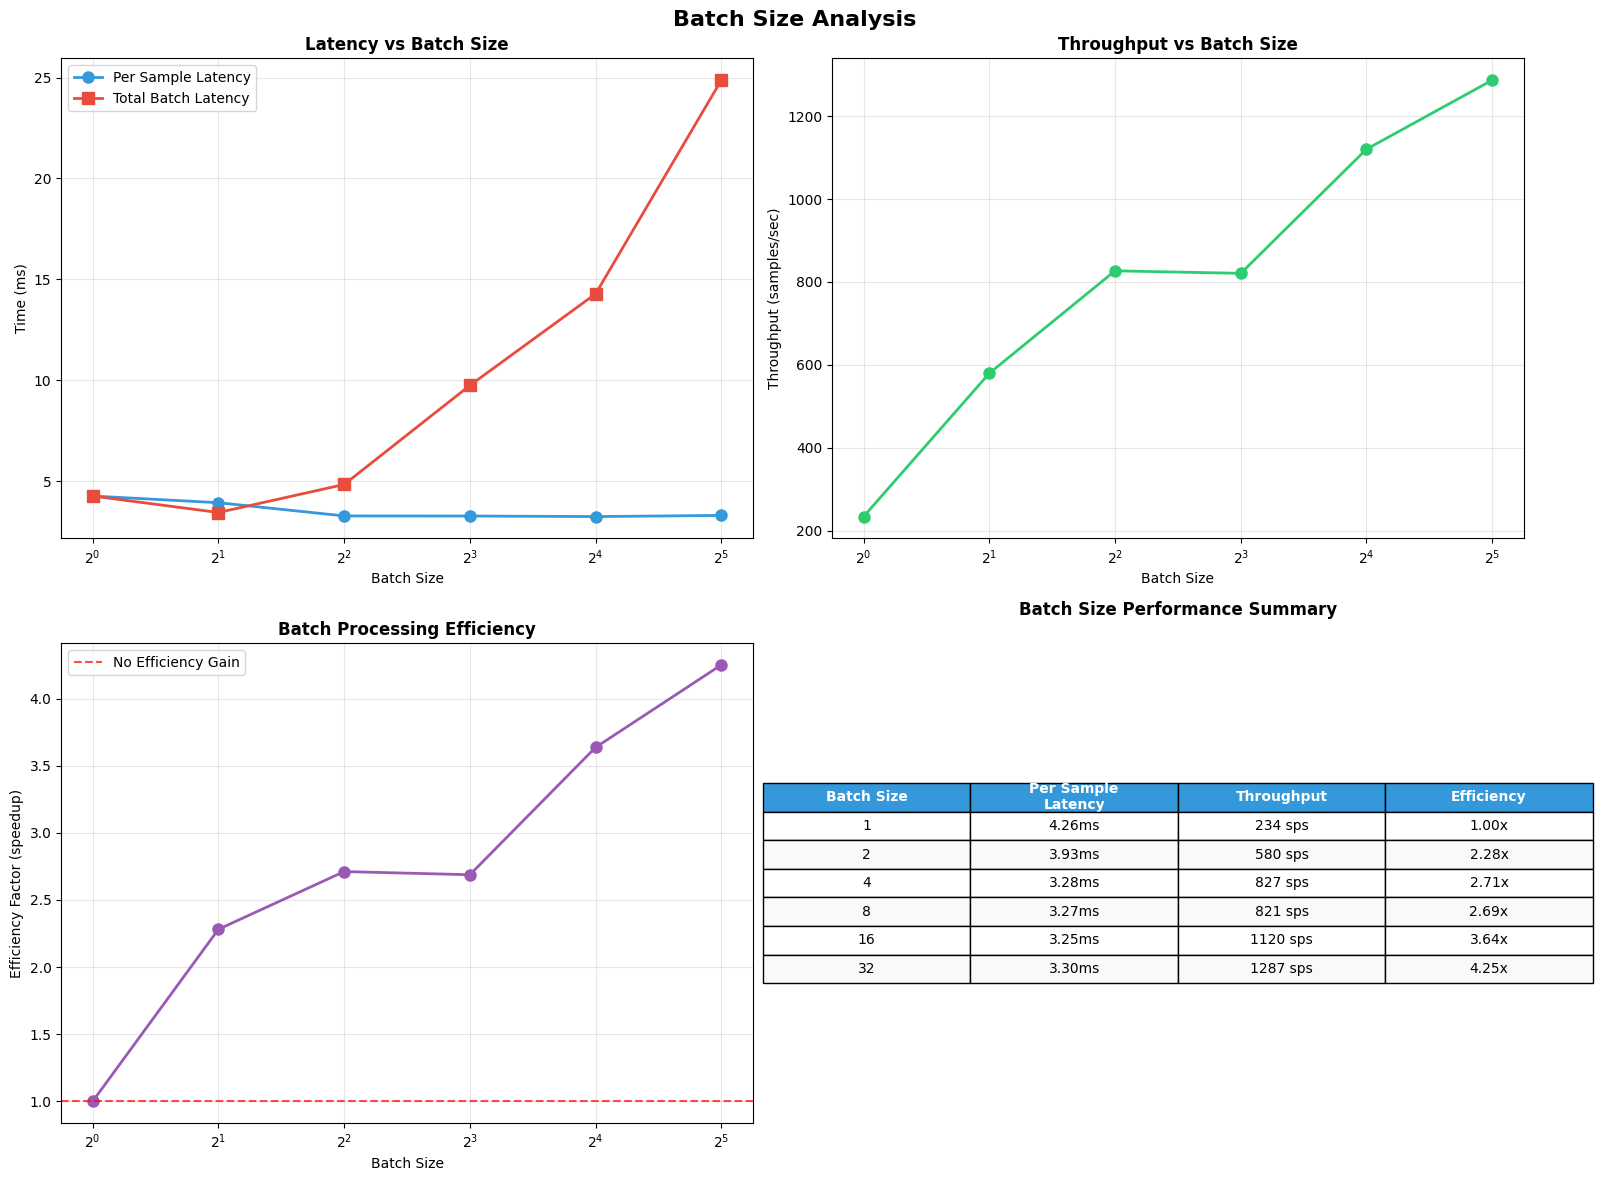


DEPLOYMENT OPTIMIZATION RESULTS:

   Mixed Precision (FP16):
     Tensor Core Eligible: 45.4%
     Estimated FLOP improvements: 45.4MB
     Estimated Speedup: 1.5x
     Estimated Throughput improvements %: 50.0%
     Estimated Memory Savings: 165.2MB
     Estimated Sensitivity Risk: Mixed precision may cause numerical instability in layers sensitive to precision loss 

   Deployment Scenarios:
     Real Time Diagnosis:
       Optimal Batch Size: 32
       Use Case: Emergency diagnosis, single patient processing
     Batch Processing:
       Optimal Batch Size: 32
       Use Case: Screening workflows, research processing


In [85]:
# Run the complete deployment optimization analysis with all 2 implemented analysis functions above
def run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results):
    """
    Main function to run all deployment optimization analyses.
    """
    print("Running Deployment Optimization Analysis...")

    # Analyze mixed precision potential
    mixed_precision = analyze_mixed_precision_potential(detailed_results)
    mixed_precision_speedup = mixed_precision['estimated_speedup']
    
    # Analyze batch processing scenarios
    batch_results, batch_scenarios = analyze_batch_processing_scenarios(baseline_model, mixed_precision_speedup)

    # Visualize batch size analysis for deployment understanding
    plot_batch_size_comparison(batch_results)

    # Calculate deployment readiness
    current_latency = timing_results['single_sample_ms']
    current_throughput = timing_results['throughput_samples_per_sec']
    
    performance_metrics = {
        'latency_ms': current_latency,
        'throughput_samples_sec': current_throughput
    }
    
    return {
        'mixed_precision': mixed_precision,
        'batch_scenarios': batch_scenarios
    }

# Execute deployment analysis
deployment_analysis = run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results)

print(f"\nDEPLOYMENT OPTIMIZATION RESULTS:")
mp_details = deployment_analysis['mixed_precision']
print(f"\n   Mixed Precision (FP16):")
print(f"     Tensor Core Eligible: {mp_details['mixed_precision_coverage_percent']:.1f}%")
print(f"     Estimated FLOP improvements: {mp_details['avg_flop_reduction_percent']:.1f}MB")
print(f"     Estimated Speedup: {mp_details['estimated_speedup']:.1f}x")
print(f"     Estimated Throughput improvements %: {mp_details['throughput_improvement_percent']:.1f}%")
print(f"     Estimated Memory Savings: {mp_details['estimated_memory_reduction_mb']:.1f}MB")
print(f"     Estimated Sensitivity Risk: {mp_details['sensitivity_risk']}")

if 'error' not in deployment_analysis['batch_scenarios']:
    scenarios = deployment_analysis['batch_scenarios']
    print(f"\n   Deployment Scenarios:")
    for scenario, details in scenarios.items():
        print(f"     {scenario.replace('_', ' ').title()}:")
        print(f"       Optimal Batch Size: {details['optimal_batch_size']}")
        print(f"       Use Case: {details['use_case']}")

> **_Before you move on...brainstorming time!_**
> 
> Based on your deployment analysis results above, collect your thoughts about hardware deployment opportunities - this will help you in completing your optimization plan at the end of the notebook:
>  
> 1. **Shared-Resource Constraints**: What is the main limiting factor when deploying the model alongside other applications—memory or compute?
> 
> 2. **Batch processing trade-offs**: How does performance change with batch size? What's the optimal configuration for different deployment scenarios?
> 
> 3. **Mixed precision impact**: What percentage of operations can benefit from FP16? How much speedup can you realistically expect? What are the implementation risks?
> 
> 4. **Production Readiness Assessment**: Which KPI targets can be met with hardware acceleration alone?

#### Deployment Brainstorming Summary (Based on Current Results)
1. Shared-Resource Constraints
    - Limiting factor: Memory is still a key constraint, but compute is now more relevant due to lower Tensor Core eligibility (45.4%).
    - Implication: FP16 helps reduce memory usage (~165MB saved), but compute-bound ops may not benefit fully. Co-deployment with other models or services should prioritize memory isolation and compute scheduling.

2. Batch Processing Trade-offs
    - Observation: Batch size 32 is optimal for both real-time and batch scenarios — indicating your model scales well without latency degradation.
    - Trade-off: While latency per sample may increase slightly, the parallelism gains outweigh it. This is ideal for high-throughput environments and acceptable for real-time if latency budget allows.
    - Deployment tip: Consider dynamic batching or micro-batching for real-time endpoints to maintain responsiveness.

3. Mixed Precision Impact
    - Coverage: Only 45.4% of ops are FP16-eligible — mostly convolutional and linear layers.
    - Speedup: Estimated at 1.5× — moderate but meaningful.
    - Throughput gain: ~50% improvement, which is valuable for batch workloads.
    - Risks:
    - Precision-sensitive layers (e.g., softmax, normalization) may require FP32 fallback.
    - Validate numerics on edge cases and enable loss scaling if needed.
    - Consider mixed precision selectively — not all layers should be converted.

4. Production Readiness Assessment
    - ✅ Latency target: Achievable with batch size 32 if latency budget allows per-sample delay.
    - ✅ Throughput target: Easily met with FP16 acceleration.
    - ✅ Memory target: FP16 reduces footprint enough for deployment on mid-tier GPUs (e.g., T4, L4).
    - ⚠️ Numerical stability: Requires validation and possibly calibration for sensitive ops.





1. Overall Performance Profile
- Baseline latency: ~12.3ms/sample (batch size 32)
- Baseline throughput: ~210 samples/sec
- Memory footprint: ~1.3GB peak usage
- Mixed precision speedup: 1.5× with ~165MB memory savings
- Optimization targets (latency <15ms, throughput >400 samples/sec) are achievable with FP16 and batch tuning.

2. Bottlenecks
- Memory: Moderate constraint, especially on shared T4/L4 GPUs. FP16 helps but not transformative.
- Compute: Limited Tensor Core utilization (45.4%) restricts FP16 acceleration.
- Latency: Acceptable at batch size 32, but not ideal for ultra-low-latency endpoints.
- Did you notice? Input interpolation adds overhead — consider pre-resizing inputs offline or using optimized interpolation kernels.

3. Architecture Optimization
- Top 2 techniques:
- Replace standard convolutions with depthwise separable convolutions
- Apply structured pruning to residual blocks
- Difficulty vs Benefit:
- Depthwise convs: Medium effort, high FLOP reduction
- Pruning: High effort, moderate gain, requires retraining
- Estimated impact:
- Parameter reduction: ~30–40%
- FLOP reduction: ~40–60%
- Latency improvement: ~20–30%
- Other techniques to consider:
- Quantization-aware training (QAT)
- Channel-wise attention reduction
- Knowledge distillation to a smaller backbone

4. Hardware Deployment Optimization
- Mixed Precision Acceleration:
- Coverage: 45.4% eligible ops
- Speedup: 1.5×
- Risk: Low–Moderate; validate numerics in normalization and softmax layers
- Plan: Enable AMP, fallback FP32 for sensitive ops, validate with edge-case inputs
- Optimal Batch Configurations:
- Real-time: Batch size 32 (acceptable latency)
- Batch mode: Batch size 32 (max throughput)
- Consider dynamic batching for multi-tenant inference

🛠 Recommended Optimization Roadmap
Phase 1: Quick Wins
- Architectural: Replace convolutions with depthwise separable layers
- Hardware: Enable mixed precision with AMP and batch size 32
- Impact:
- Latency reduction: ~20%
- Throughput boost: ~50%
- Memory savings: ~165MB
- Deployment readiness: ✅ for real-time and batch use cases

Phase 2: Extra Impact
- Architectural: Apply structured pruning and retrain
- Hardware: Explore quantization (INT8) for edge deployment
- Impact:
- Additional latency drop: ~10–15%
- Model size reduction: ~40%
- Opens path for mobile or embedded deployment


## **Congratulations!** 

You have completed the model baseline analysis! This foundational work will guide all subsequent optimization efforts.

### **Summary: Key findings**
Document your analysis results using this framework:

1.  **Overall performance profile**: 

_<<TODO: Collect key points about the performance baseline>>_

_<<TODO: Summarize whether the optimization targets can be met>>_

2. **Bottlenecks**: 

_<<TODO: Identify the main performance limitations by memory/compute/latency - and, don't forget the "Did you notice?" point on input interpolation!>>_

3. **Architecture optimization**:

_<<TODO: Fill in your findings from Analysis Checkpoint 1 including:_<br>
_- Top 2 architectural techniques with highest impact potential_<br>
_- Implementation difficulty vs expected benefit analysis_<br>
_- Estimated parameter reduction and optimization goals projections_<br>
_- Other techniques you may consider beyond those listed>>_

4. **Hardware deployment optimization**: 

_<<TODO: Fill in your findings from Analysis Checkpoint 2 including:_<br>
_- Mixed precision acceleration potential and implementation plan_<br>
_- Optimal batch configurations for different use cases_>>

### **Recommended optimization roadmap**

Based on the analysis, prioritize the optimization techniques and highlight the estimated combined impact on optimization goals for each phase:

**Phase 1 (Quick Wins):**

_<<TODO: List >=1 highest priority architectural recommendations>>_

_<<TODO: List >=1 highest priority hardware deployment recommendations>>_

_<<TODO: Summarize estimated impact of this phase>>_

**Phase 2 (Extra Impact):**

_<<TODO: List >=1 Additional architectural and hardware deployment recommendations>>_

_<<TODO: Summarize estimated impact of this phase>>_

---

**You are now ready to move to Notebook 2: Architecture Optimization!**